In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from feature_engine.selection import DropConstantFeatures, DropDuplicateFeatures, SmartCorrelatedSelection, SelectBySingleFeaturePerformance
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
train = pd.read_csv("../../Data/Dataset-v2/train_B.csv")
val = pd.read_csv("../../Data/Dataset-v2/val_B.csv")
test = pd.read_csv("../../Data/Dataset-v2/test_B.csv")

In [3]:
train.shape, test.shape, val.shape

((1117830, 34), (319400, 34), (159690, 34))

The number of samples (as well as the number of features later on) is reduced proportionally because of the QSVM computational limitations (We need to reach 15 features).
But instead of using methods like RF importance for feature reduction, we'll use optimized methods for SVMs: 1st correlation feature reduction; 2nd wrapper feature reduction (based on SVM performance in specific features)

In [6]:
porcentaje_mantener = 0.001

train_reducido_udp = train[train['proto'] == 1].groupby('category').sample(frac=porcentaje_mantener)
train_reducido_tcp = train[train['proto'] == 0].groupby('category').sample(frac=porcentaje_mantener)

train_reducido = pd.concat([train_reducido_udp, train_reducido_tcp])


test_reducido_udp = test[test['proto'] == 1].groupby('category').sample(frac=porcentaje_mantener)
test_reducido_tcp = test[test['proto'] == 0].groupby('category').sample(frac=porcentaje_mantener)

test_reducido = pd.concat([test_reducido_udp, test_reducido_tcp])

In [7]:
train_reducido.shape, test_reducido.shape

((1119, 34), (320, 34))

In [8]:
# Separar características y etiquetas para conjunto de entrenamiento
X_train_reducido = train_reducido.drop(columns=['category'])
y_train_reducido = train_reducido['category']

# Separar características y etiquetas para conjunto de prueba
X_test_reducido = test_reducido.drop(columns=['category'])
y_test_reducido = test_reducido['category']

In [9]:
column_names = X_train_reducido.columns

#Normalización del conjunto de datos reducido
norm = StandardScaler()

X_train_reducido = pd.DataFrame(norm.fit_transform(X_train_reducido), columns=column_names)
X_test_reducido = pd.DataFrame(norm.transform(X_test_reducido), columns=column_names)


In [10]:
SVM = svm.SVC(kernel='rbf', gamma='scale')

param_grid = {'C': list(np.arange(0.1, 40, 1))}
grid = GridSearchCV(estimator=SVM, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)
grid.fit(X_train_reducido, y_train_reducido)

print('Best Parameters:', grid.best_params_)
print('Best Cross Validation Score:', grid.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'C': np.float64(25.1)}
Best Cross Validation Score: 0.6335762331838565


In [11]:
SVM =  grid.best_estimator_

y_train_pred = SVM.predict(X_train_reducido)

start2 = time.time()
y_test_pred = SVM.predict(X_test_reducido)
stop2 = time.time()

print('Train Accuracy:', accuracy_score(y_train_reducido, y_train_pred))
print('Test Accuracy: ', accuracy_score(y_test_reducido, y_test_pred))

tiempo2 = stop2 - start2
print(f"Support Vector Machine Test Prediction Time: {tiempo2}s")

Train Accuracy: 0.7372654155495979
Test Accuracy:  0.653125
Support Vector Machine Test Prediction Time: 0.023442745208740234s


# CORRELATION FEATURE REDUCTION STARTS

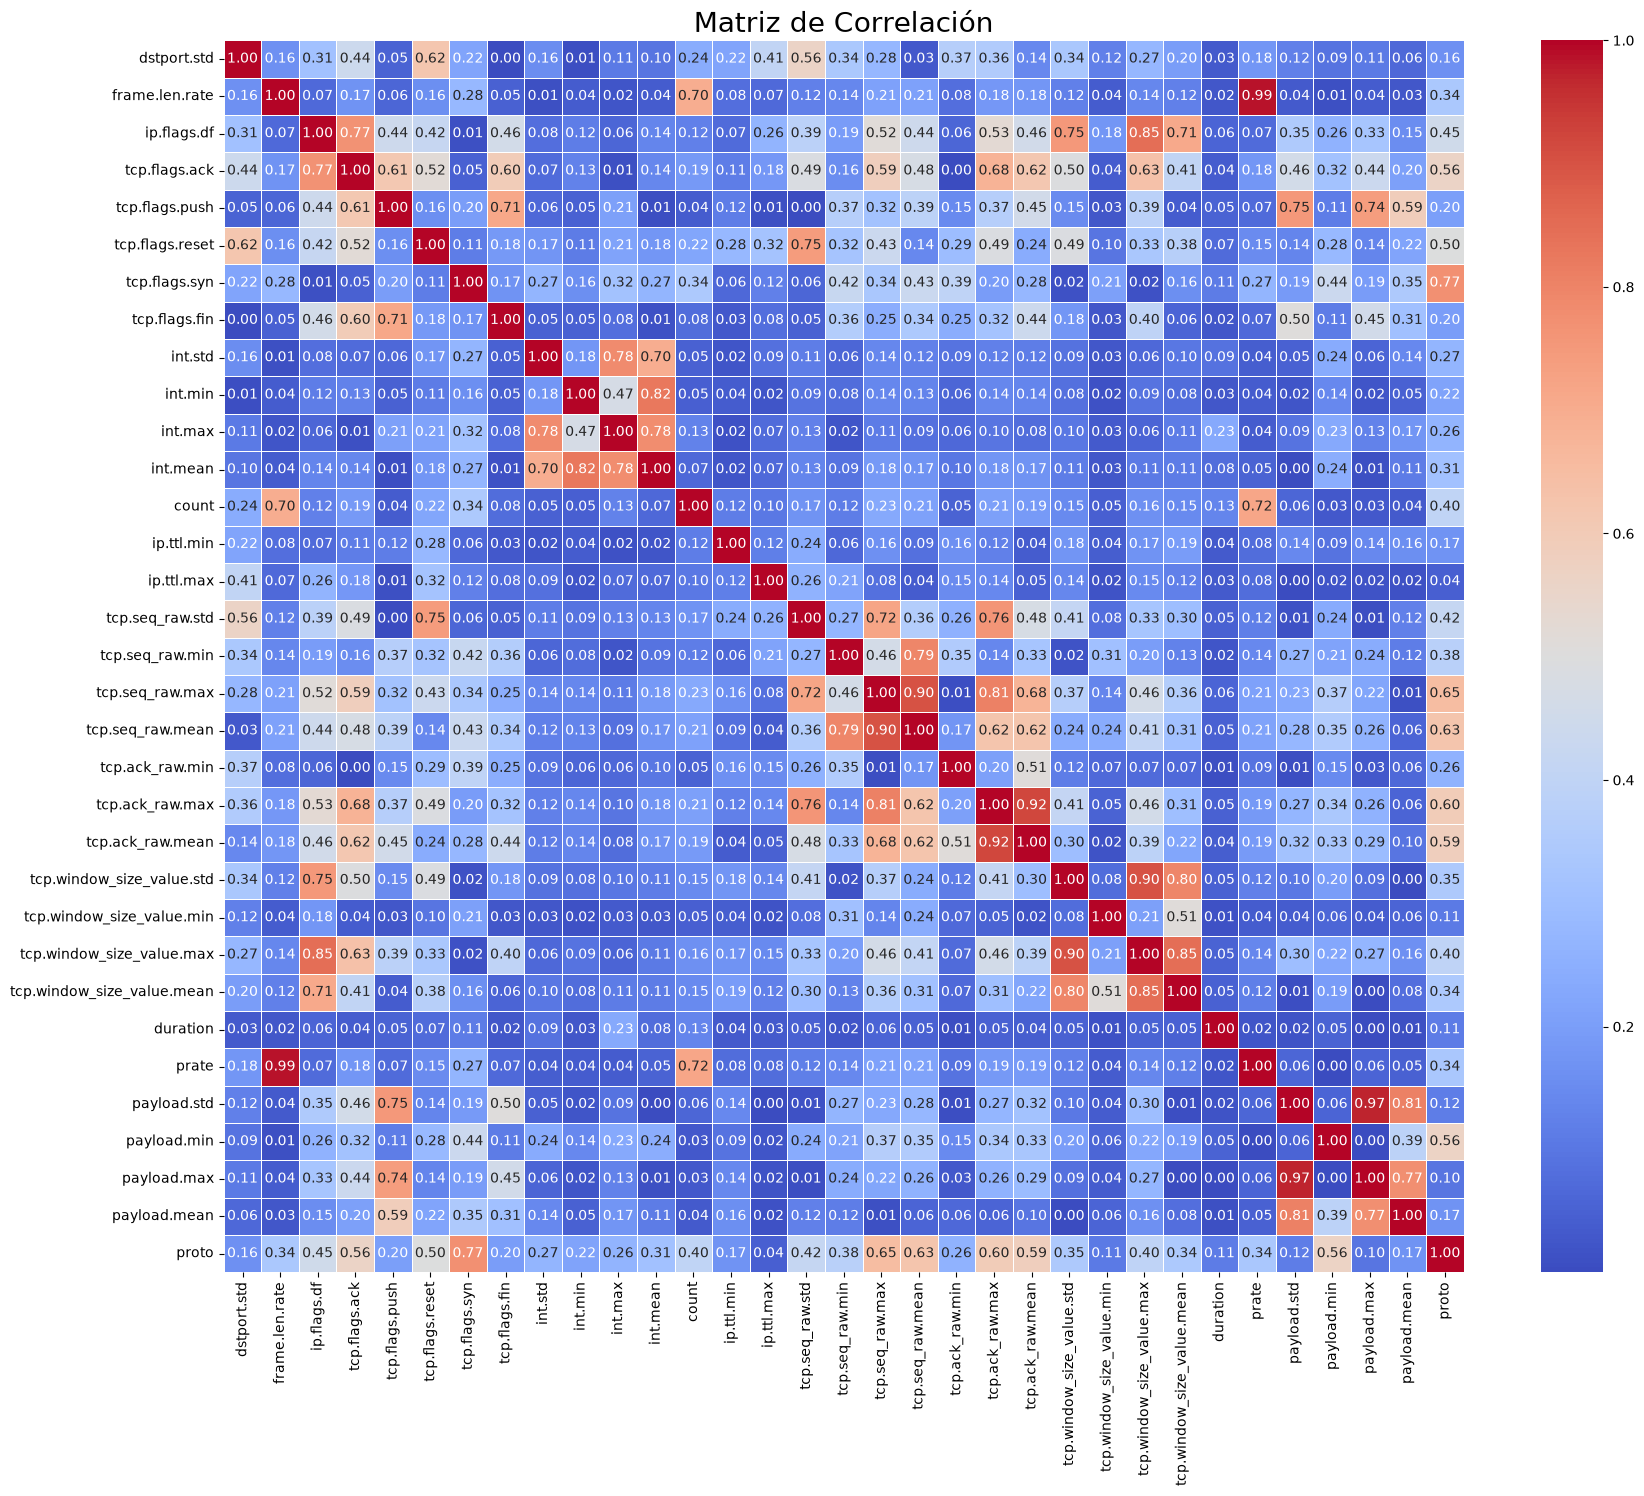

In [12]:
corr_matrix = X_train_reducido.corr().abs()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Matriz de Correlación", fontsize=20)
plt.show()

Used to check every single group of highly correlated features

In [14]:
def correlation(dataset, threshold):
    
    # create a set where I will store the names of correlated columns. Sets cannot contain duplicated elements
    col_corr = set()
    
    corr_matrix = dataset.corr()
    
    for i in range(len(corr_matrix.columns)):
        
        # check with other features (Not with itself)
        for j in range(i):
            
            # if the correlation is higher than a certain threshold
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value

                print(abs(corr_matrix.iloc[i, j]), corr_matrix.columns[i], corr_matrix.columns[j])
                
                # get the name of the correlated feature
                colname = corr_matrix.columns[j]
                
                # and add it to our correlated set
                col_corr.add(colname)
                
    return col_corr

In [18]:
corr_features = correlation(X_train_reducido, 0.78)
len(set(corr_features))

0.7844614101208662 int.max int.std
0.8249386885279024 int.mean int.min
0.7941945324079117 tcp.seq_raw.mean tcp.seq_raw.min
0.9005976933321205 tcp.seq_raw.mean tcp.seq_raw.max
0.8062107756092111 tcp.ack_raw.max tcp.seq_raw.max
0.920343846592859 tcp.ack_raw.mean tcp.ack_raw.max
0.847706250413857 tcp.window_size_value.max ip.flags.df
0.8994001142529513 tcp.window_size_value.max tcp.window_size_value.std
0.7951327823379476 tcp.window_size_value.mean tcp.window_size_value.std
0.8475722530559763 tcp.window_size_value.mean tcp.window_size_value.max
0.9876104231368364 prate frame.len.rate
0.9714150609061577 payload.max payload.std
0.8087100729279477 payload.mean payload.std


10

In [19]:
sel = SmartCorrelatedSelection(
    variables=None, # if none, selector examines all numerical variables
    method="pearson",
    threshold=0.80, # Above 80% is considered hihly correlated
    missing_values="raise",
    selection_method="model_performance",
    estimator=SVM,
    scoring="accuracy",
    cv=5,
)

sel.fit(X_train_reducido, y_train_reducido)

,missing_values,'raise'
,selection_method,'model_performance'
,estimator,SVC(C=np.float64(25.1))
,scoring,'accuracy'
,cv,5
,variables,None
,method,'pearson'
,threshold,0.8
,groups,None
,confirm_variables,False
Name,Type,Value


In [20]:
sel.correlated_feature_sets_

[{'frame.len.rate', 'prate'},
 {'int.mean', 'int.min'},
 {'ip.flags.df', 'tcp.window_size_value.max'},
 {'payload.max', 'payload.std'},
 {'tcp.ack_raw.max', 'tcp.ack_raw.mean', 'tcp.seq_raw.max'}]

In [21]:
corr_features = sel.features_to_drop_
corr_features

['prate',
 'int.min',
 'ip.flags.df',
 'payload.std',
 'tcp.ack_raw.max',
 'tcp.ack_raw.mean']

In [22]:
X_train_reducido.drop(columns=corr_features, inplace=True)
X_test_reducido.drop(columns=corr_features, inplace=True)

X_train_reducido.shape, X_test_reducido.shape

((1119, 27), (320, 27))

In [23]:
# Ver los valores NaN en cada columna de X_train
nan_counts = X_train_reducido.isna().sum()

# Mostrar las columnas que tienen valores NaN
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


Interpret these results with respect to the previous training

In [24]:
SVM = svm.SVC(kernel='rbf', gamma='scale')

param_grid = {'C': list(np.arange(0.1, 40, 1))}
grid = GridSearchCV(estimator=SVM, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)
grid.fit(X_train_reducido, y_train_reducido)

print('Best Parameters:', grid.best_params_)
print('Best Cross Validation Score:', grid.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'C': np.float64(15.1)}
Best Cross Validation Score: 0.6300088084561178


In [25]:
SVM =  grid.best_estimator_

y_train_pred = SVM.predict(X_train_reducido)

start2 = time.time()
y_test_pred = SVM.predict(X_test_reducido)
stop2 = time.time()

print('Train Accuracy:', accuracy_score(y_train_reducido, y_train_pred))
print('Test Accuracy: ', accuracy_score(y_test_reducido, y_test_pred))

tiempo2 = stop2 - start2
print(f"Support Vector Machine Test Prediction Time: {tiempo2}s")

Train Accuracy: 0.7283288650580876
Test Accuracy:  0.65625
Support Vector Machine Test Prediction Time: 0.025682687759399414s


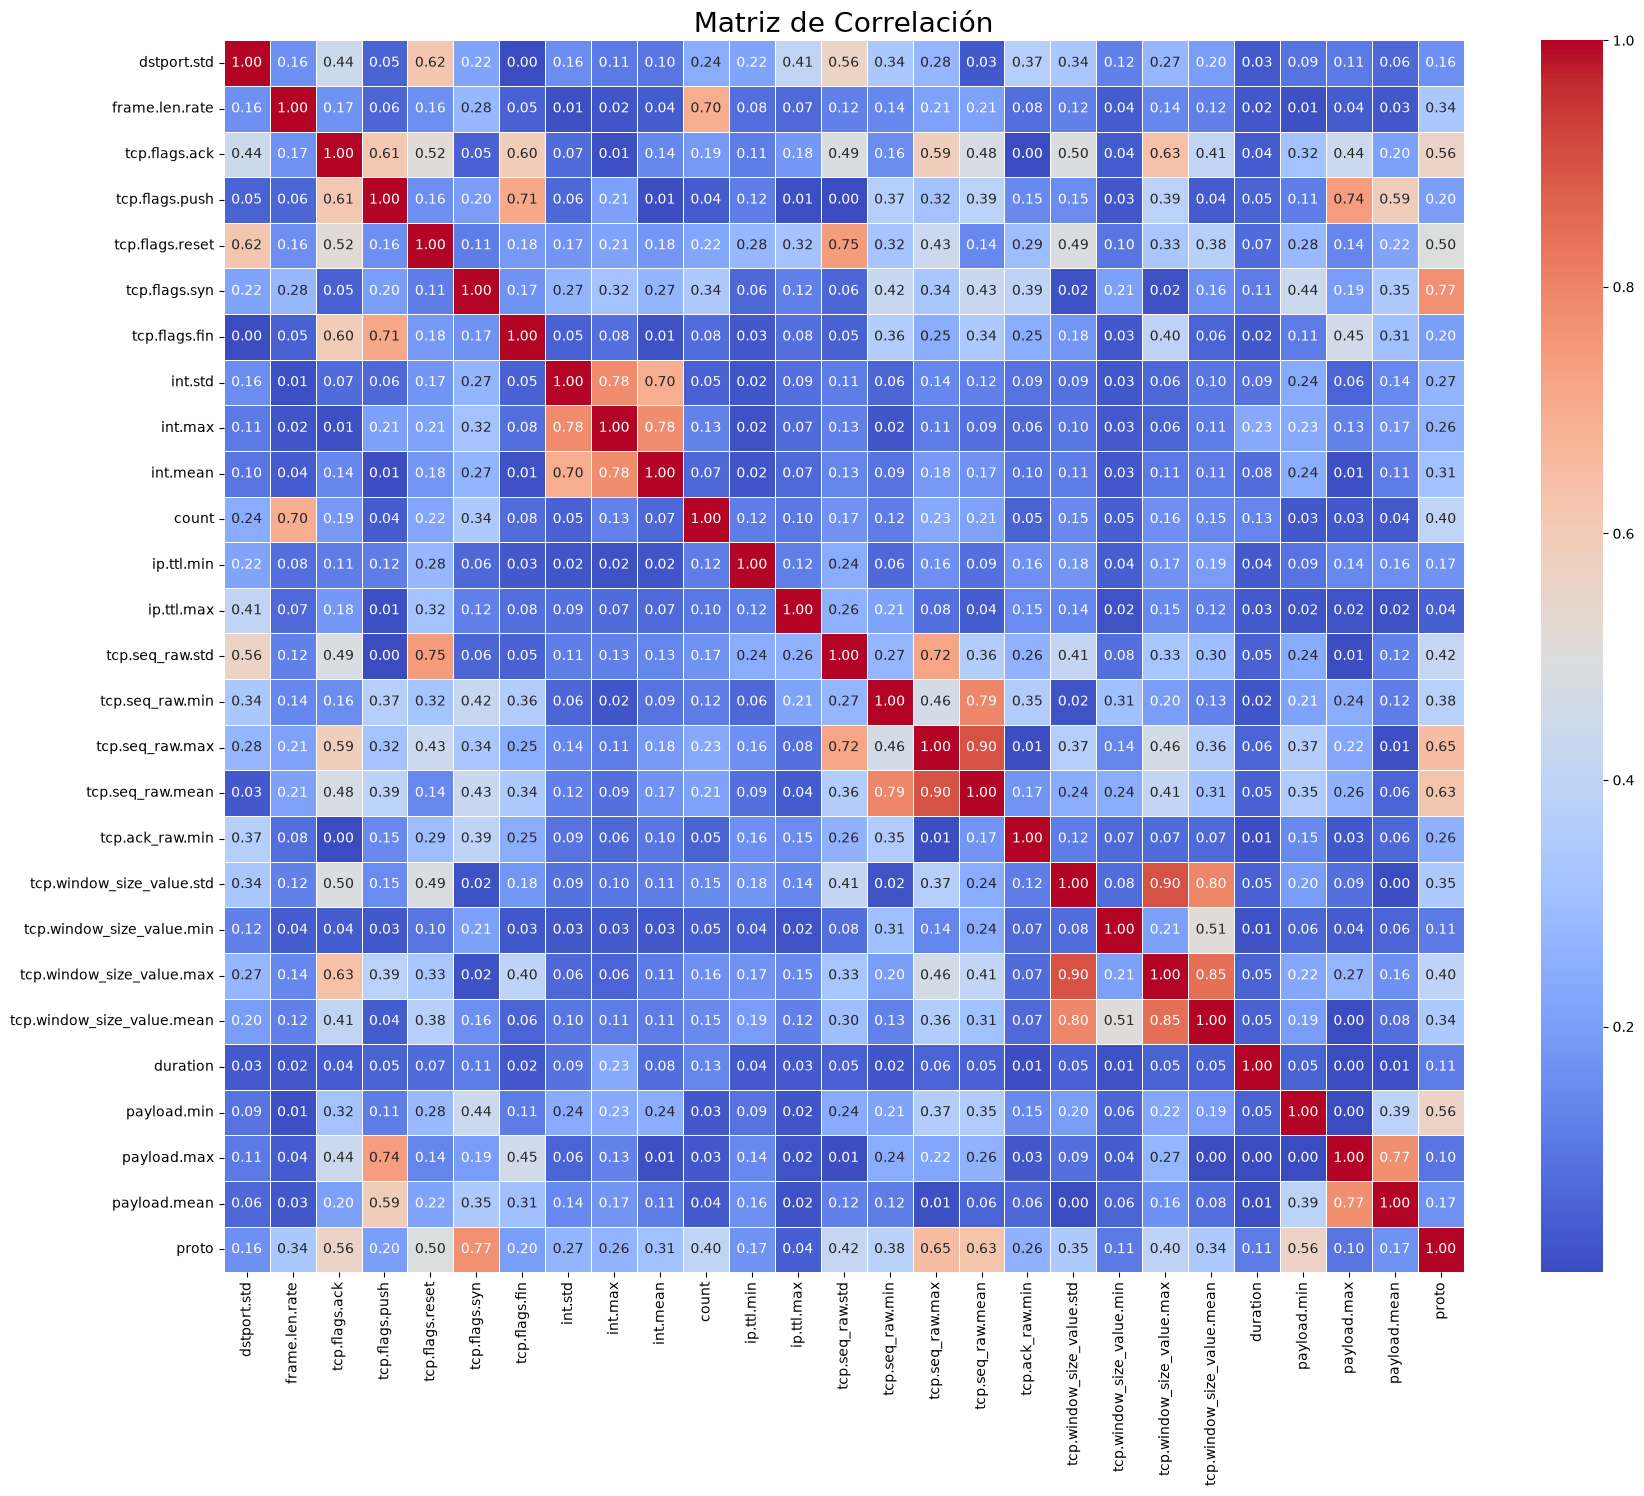

In [26]:
corr_matrix = X_train_reducido.corr().abs()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Matriz de Correlación", fontsize=20)
plt.show()

It is necessary to exceute it again, as it does not identify all highly correlated groups in just one execution (it takes two in this case)

In [27]:
sel = SmartCorrelatedSelection(
    variables=None, # if none, selector examines all numerical variables
    method="pearson",
    threshold=0.78,
    missing_values="raise",
    selection_method="model_performance",
    estimator=SVM,
    scoring="accuracy",
    cv=5,
)

sel.fit(X_train_reducido, y_train_reducido)

,threshold,0.78
,missing_values,'raise'
,selection_method,'model_performance'
,estimator,SVC(C=np.float64(15.1))
,scoring,'accuracy'
,cv,5
,variables,None
,method,'pearson'
,groups,None
,confirm_variables,False
Name,Type,Value


In [28]:
sel.correlated_feature_sets_

[{'int.max', 'int.std'},
 {'tcp.seq_raw.max', 'tcp.seq_raw.mean'},
 {'tcp.window_size_value.max',
  'tcp.window_size_value.mean',
  'tcp.window_size_value.std'}]

In [30]:
corr_features = sel.features_to_drop_
corr_features

['int.std',
 'tcp.seq_raw.mean',
 'tcp.window_size_value.mean',
 'tcp.window_size_value.std']

In [32]:
X_train_reducido.drop(columns=corr_features, inplace=True)
X_test_reducido.drop(columns=corr_features, inplace=True)

X_train_reducido.shape, X_test_reducido.shape

((1119, 23), (320, 23))

Interpret these results with respect to the previous training

In [35]:
SVM = svm.SVC(kernel='rbf', gamma='scale')

param_grid = {'C': list(np.arange(0.1, 40, 1))}
grid = GridSearchCV(estimator=SVM, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)
grid.fit(X_train_reducido, y_train_reducido)

print('Best Parameters:', grid.best_params_)
print('Best Cross Validation Score:', grid.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'C': np.float64(15.1)}
Best Cross Validation Score: 0.6371596732863549


In [36]:
SVM =  grid.best_estimator_

y_train_pred = SVM.predict(X_train_reducido)

start2 = time.time()
y_test_pred = SVM.predict(X_test_reducido)
stop2 = time.time()

print('Train Accuracy:', accuracy_score(y_train_reducido, y_train_pred))
print('Test Accuracy: ', accuracy_score(y_test_reducido, y_test_pred))

tiempo2 = stop2 - start2
print(f"Support Vector Machine Test Prediction Time: {tiempo2}s")

Train Accuracy: 0.7301161751563896
Test Accuracy:  0.65
Support Vector Machine Test Prediction Time: 0.02353811264038086s


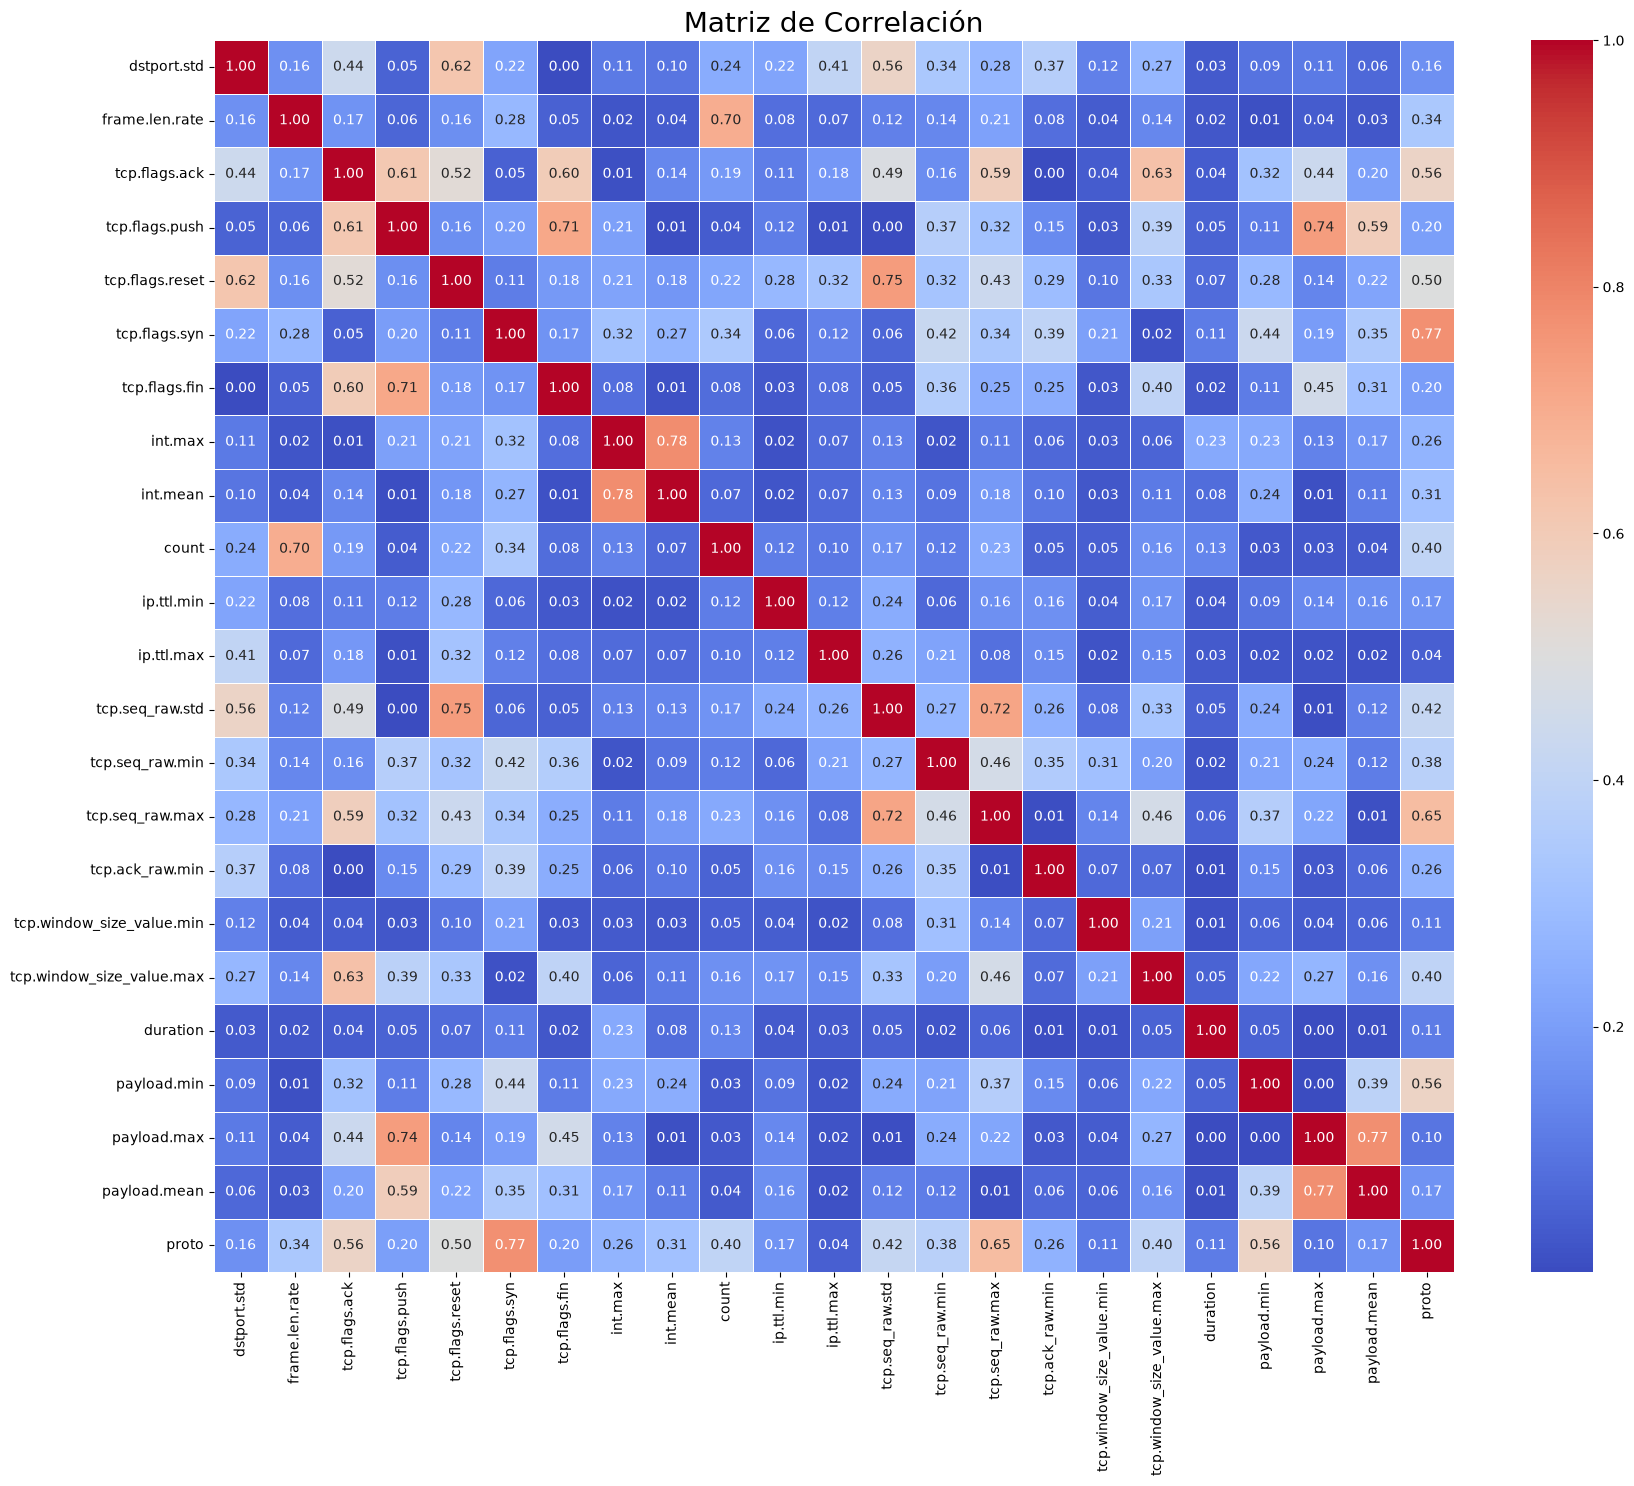

In [37]:
corr_matrix = X_train_reducido.corr().abs()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Matriz de Correlación", fontsize=20)
plt.show()

# WRAPPER FEATURE SELECTION

## Univariate Performance

This procedure works as follows:

- Train a ML model per every single feature
- Determine the performance of the models
- Select features if model performance is above a certain threshold

It uses cross-validation.

In [44]:
X_train_reducido = X_train_reducido.reset_index(drop=True)
y_train_reducido = y_train_reducido.reset_index(drop=True)

X_test_reducido = X_test_reducido.reset_index(drop=True)
y_test_reducido = y_test_reducido.reset_index(drop=True)

In [52]:
# set up the selector
sel = SelectBySingleFeaturePerformance(
    variables=None, # automatically evaluate all numerical variables
    estimator=SVM, 
    scoring="accuracy",
    cv=3,
    threshold=0.2015, #Because we want to keep 15 features
)

# find predictive features
sel.fit(X_train_reducido, y_train_reducido)

,estimator,SVC(C=np.float64(15.1))
,scoring,'accuracy'
,threshold,0.2015
,cv,3
,groups,None
,variables,None
,confirm_variables,False
Name,Type,Value
feature_names_in_,list,"['ds...td', 'fr...te', 'tc...ck', 'tc...sh', ...]"
feature_performance_,dict,"{'count': np.float64(0....5540661304736), 'ds...td': np.float64(0....0259159964253), 'du...on': np.float64(0....2162645218945), 'fr...te': np.float64(0.1867739052725648), ...}"
feature_performance_std_,dict,"{'count': np.float64(0....7080142023396), 'ds...td': np.float64(0....7502031767549), 'du...on': np.float64(0....5753592885478), 'fr...te': np.float64(0....7502281866421), ...}"


In [53]:
len(sel.features_to_drop_)

8

In [54]:
sel.feature_performance_

{'dstport.std': np.float64(0.21090259159964253),
 'frame.len.rate': np.float64(0.1867739052725648),
 'tcp.flags.ack': np.float64(0.2421805183199285),
 'tcp.flags.push': np.float64(0.13672922252010725),
 'tcp.flags.reset': np.float64(0.2287756925826631),
 'tcp.flags.syn': np.float64(0.3199285075960679),
 'tcp.flags.fin': np.float64(0.13315460232350312),
 'int.max': np.float64(0.2439678284182306),
 'int.mean': np.float64(0.22073279714030383),
 'count': np.float64(0.30205540661304736),
 'ip.ttl.min': np.float64(0.16979445933869527),
 'ip.ttl.max': np.float64(0.20196604110813224),
 'tcp.seq_raw.std': np.float64(0.19481680071492405),
 'tcp.seq_raw.min': np.float64(0.20107238605898123),
 'tcp.seq_raw.max': np.float64(0.24039320822162646),
 'tcp.ack_raw.min': np.float64(0.20554066130473636),
 'tcp.window_size_value.min': np.float64(0.26094727435210013),
 'tcp.window_size_value.max': np.float64(0.26005361930294907),
 'duration': np.float64(0.20822162645218945),
 'payload.min': np.float64(0.304

Text(0, 0.5, 'accuracy')

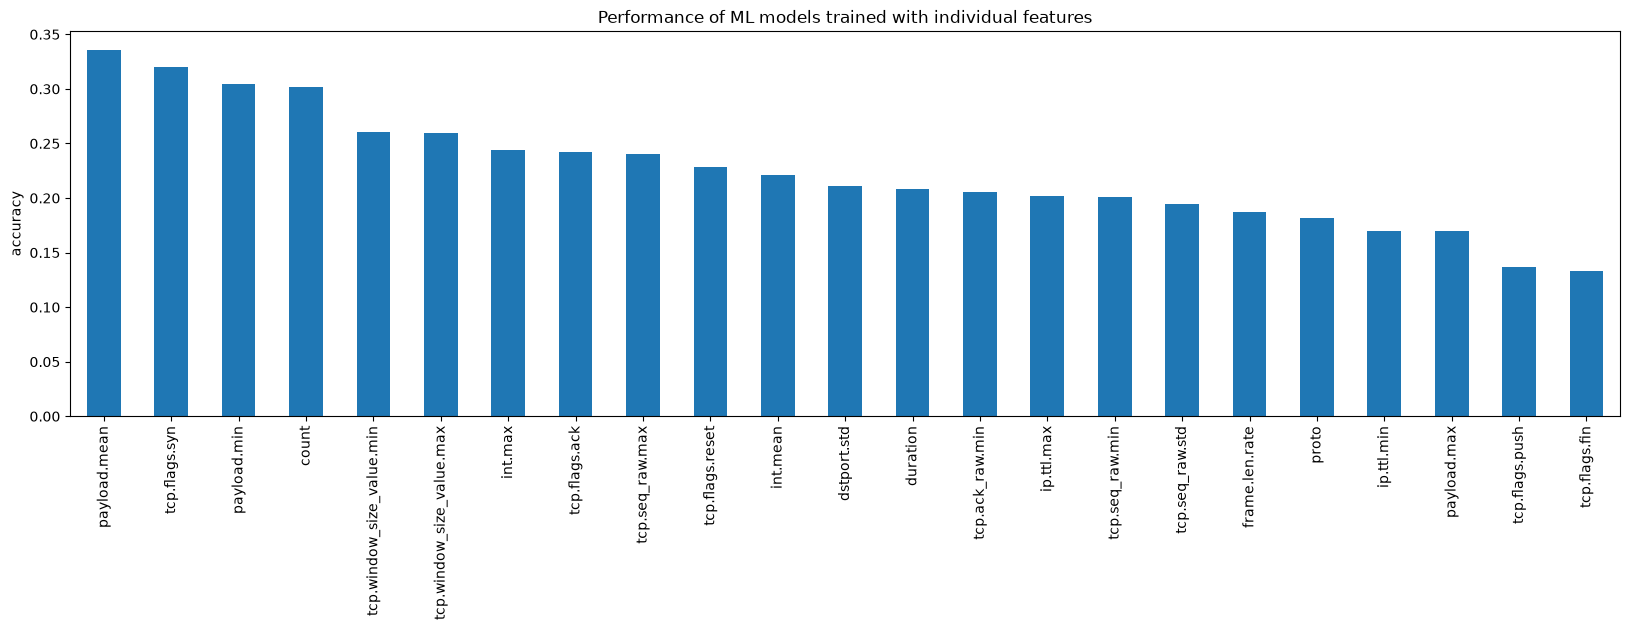

In [55]:
pd.Series(sel.feature_performance_).sort_values(ascending=False).plot.bar(figsize=(20, 5))
plt.title('Performance of ML models trained with individual features')
plt.ylabel('accuracy')

In [ ]:
X_train = sel.transform(X_train_reducido)
X_test = sel.transform(X_test_reducido)

X_train.shape, X_test.shape

((1119, 15), (320, 15))

Interpret these results with respect the previous results

In [59]:
SVM = svm.SVC(kernel='rbf', gamma='scale')

param_grid = {'C': list(np.arange(0.1, 40, 1))}
grid = GridSearchCV(estimator=SVM, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)
grid.fit(X_train, y_train_reducido)

print('Best Parameters:', grid.best_params_)
print('Best Cross Validation Score:', grid.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'C': np.float64(27.1)}
Best Cross Validation Score: 0.6300168161434978


In [60]:
SVM =  grid.best_estimator_

y_train_pred = SVM.predict(X_train)

start2 = time.time()
y_test_pred = SVM.predict(X_test)
stop2 = time.time()

print('Train Accuracy:', accuracy_score(y_train_reducido, y_train_pred))
print('Test Accuracy: ', accuracy_score(y_test_reducido, y_test_pred))

tiempo2 = stop2 - start2
print(f"Support Vector Machine Test Prediction Time: {tiempo2}s")

Train Accuracy: 0.7220732797140303
Test Accuracy:  0.628125
Support Vector Machine Test Prediction Time: 0.02248215675354004s


Interpret the confussion matrix (really poor results compared to Random Forest)

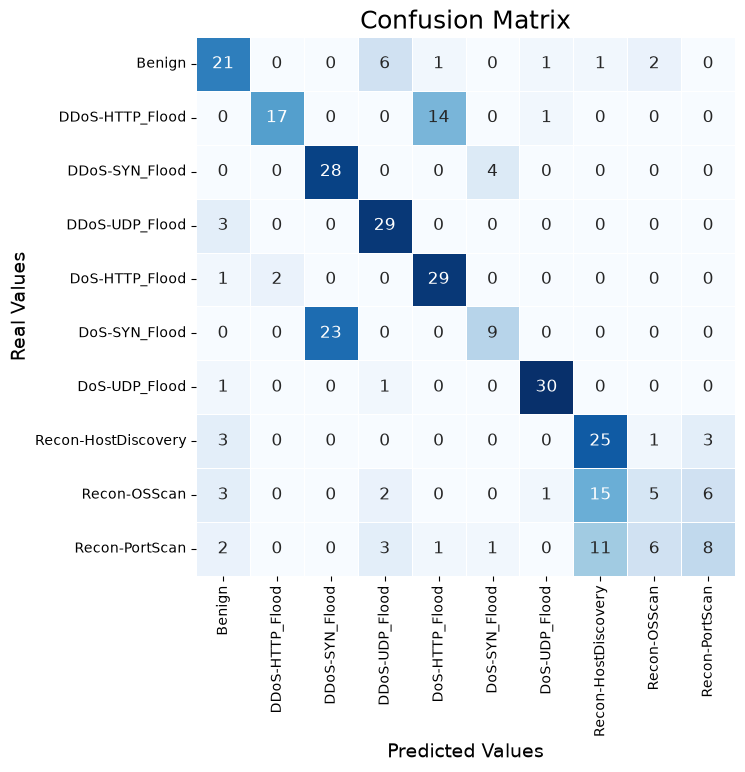

In [64]:
cm = metrics.confusion_matrix(y_test_reducido, y_test_pred)
normalized_matrix = cm

class_names = ['Benign', 'DDoS-HTTP_Flood', 'DDoS-SYN_Flood', 'DDoS-UDP_Flood', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-UDP_Flood', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PortScan']

# Plot
sns.heatmap(
    normalized_matrix, 
    annot=True, 
    fmt='0.0f', 
    linewidth=0.5,
    annot_kws={"size": 12}, 
    xticklabels=class_names,
    yticklabels=class_names, 
    square=True, 
    cmap='Blues', 
    cbar=False
)

fig = plt.gcf()
fig.set_size_inches(7, 7)
plt.ylabel('Real Values', fontsize=14)
plt.xlabel('Predicted Values', fontsize=14)
plt.title('Confusion Matrix', fontsize=18)

# Guardar como PDF (¡hazlo antes del plt.show!)
plt.savefig('CM_RF_33car_10Class.pdf', format='pdf', bbox_inches='tight')

plt.show()

In [ ]:
X_train = X_train.reset_index(drop=True)
y_train = y_train_reducido.reset_index(drop=True)
train = pd.concat([X_train, y_train_reducido], axis=1)

X_test_reducido = X_test_reducido.reset_index(drop=True)
y_test_reducido = y_test_reducido.reset_index(drop=True)
test = pd.concat([X_test_reducido, y_test_reducido], axis=1)

In [44]:

train.to_csv('train_C.csv', index=False)
test.to_csv('test_C.csv', index=False)